# Donor Churn Pipeline — Real Lighthouse Data (Improved v2)

This version adds stronger donor-behavior features, a third tree model, and more robust threshold tuning to improve recall/average precision on the real dataset.

## Problem Framing

**Business Question:** Which donors are at risk of lapsing in the next 180 days, and how can the organization prioritize outreach to retain them?

**Who cares and why it matters:** Lighthouse for Life depends on recurring donor revenue to fund its residential programs, counseling services, and outreach operations. Donor acquisition is expensive — retaining an existing donor costs a fraction of replacing one. Development staff and the executive team need a reliable early-warning system to identify at-risk donors *before* they lapse, so they can target retention outreach (personal calls, impact reports, stewardship events) where it will do the most good. Without a model, staff either contact everyone (wasteful) or react after donors have already lapsed (too late).

**Predictive vs. Explanatory Approach:**
This pipeline takes a **predictive** approach. Our goal is not to establish causation — we cannot run a controlled experiment on donor behavior — but to generate reliable probability estimates for churn that generalize to new, unseen donors. Predictive modeling is judged by out-of-sample performance on new data, not by the interpretability of individual coefficients. Because staff need to act on a ranked list of at-risk donors each month, predictive accuracy on a held-out time period is the right success criterion.

**Success Metrics (defined upfront):**
- **ROC-AUC >= 0.75:** The model should rank at-risk donors well above safe donors most of the time. *Note: the model achieved 0.685 on the holdout — below this target. See the Evaluation section for a full discussion.*
- **Average Precision (AP):** Because churn is relatively frequent in this dataset (~39% of snapshots), AP is the more informative summary metric — it measures precision across all recall thresholds weighted by their frequency.
- **Recall on churners >= 0.60:** We accept some false positives (over-contacting safe donors) to avoid missing real churners. Missing a churner has a higher cost than an unnecessary outreach touchpoint. *Actual recall achieved: 0.543 — also below target.*

**Modeling Goal:** Produce a monthly churn probability score (0–1) per donor, bucketed into Low / Medium / High risk tiers, written back to the database for use in the admin retention dashboard.


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile
import pickle
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

# Config
RANDOM_STATE = 42
TARGET = "churned"
TEST_SIZE = 0.2


## 1. Extract and load the Lighthouse donor data

In [2]:
from pythondbconnection import importTableFromDb, update_supporter_likely_churn
supporters = importTableFromDb("dbo.supporters")
donations = importTableFromDb("dbo.donations")

supporters["created_at"] = pd.to_datetime(supporters["created_at"], errors="coerce")
supporters["first_donation_date"] = pd.to_datetime(supporters["first_donation_date"], errors="coerce")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")

supporters.shape, donations.shape
supporters.head(), donations.head()

(   supporter_id       supporter_type  display_name organization_name  \
 0             1  SocialMediaAdvocate  Mila Alvarez              None   
 1             2            Volunteer    Aria Brown              None   
 2             3        MonetaryDonor     Noah Chen              None   
 3             4        MonetaryDonor     Liam Diaz              None   
 4             5          InKindDonor    Emma Evans              None   
 
   first_name last_name    relationship_type    region      country  \
 0       Mila   Alvarez                Local     Luzon  Philippines   
 1       Aria     Brown                Local  Mindanao  Philippines   
 2       Noah      Chen                Local     Luzon  Philippines   
 3       Liam      Diaz  PartnerOrganization  Mindanao  Philippines   
 4       Emma     Evans  PartnerOrganization  Mindanao  Philippines   
 
                        email             phone  status created_at  \
 0  mila-alvarez@smart.com.ph  +63 997 578 1887  Active 2022-0

## Data Exploration

**Source Tables:**
- `dbo.supporters` — one row per donor; contains static attributes (supporter type, relationship type, region, acquisition channel, status).
- `dbo.donations` — one row per transaction; contains amount, date, campaign, channel, and type for every donation ever made.

These two tables are joined at the donor level to produce a rich behavioral history. The donations table is the primary source of signal — the supporters table provides demographic and segment context.

**Key Observations Before Modeling:**
- Churn is defined as *no donation in the 180 days following the snapshot date*. This is a standard industry definition for donor lapse.
- Class imbalance is expected: most donors who gave recently are not churning, which means naive accuracy is misleading. We use ROC-AUC and Average Precision as primary metrics.
- Date columns are converted to datetime at load time to enable time-aware feature engineering (recency, tenure, rolling windows).
- Missing values exist in behavioral columns for new donors who have little history — handled with median imputation rather than row deletion, because even sparse donors are worth scoring.

**Temporal Coverage:** The snapshot approach (explained in Section 2) creates multiple observations per donor across time, giving the model exposure to donors at different lifecycle stages. The train/test split is time-based to simulate real deployment conditions.

## 2. Why we use donor snapshots instead of only one row per donor

The earlier real-data notebook only created **one row per donor**, which left us with a very small dataset.
That made the model unstable and pushed it into predicting mostly the majority class.

This version creates **monthly donor snapshots**:

- For each donor
- At many monthly `as_of_date` points
- Using only donations observed up to that date
- Labeling churn as **1 if no donation occurs in the next 180 days**

That gives us a more realistic supervised learning setup and many more labeled examples.

In [3]:

def build_donor_snapshot_dataset(
    donations_df: pd.DataFrame,
    supporters_df: pd.DataFrame,
    asof_start: str = "2024-01-01",
    asof_end: str = "2025-09-01",
    freq: str = "MS",
    horizon_days: int = 180,
    min_history_days: int = 30,
) -> pd.DataFrame:
    """Create one row per donor per snapshot date using only historical information."""

    donations_df = donations_df.sort_values(["supporter_id", "donation_date"]).copy()
    snapshot_dates = pd.date_range(asof_start, asof_end, freq=freq)

    rows = []

    for supporter_id, grp in donations_df.groupby("supporter_id"):
        grp = grp.sort_values("donation_date").copy()

        first_donation = grp["donation_date"].min()

        for as_of_date in snapshot_dates:
            past = grp[grp["donation_date"] <= as_of_date].copy()
            future = grp[
                (grp["donation_date"] > as_of_date) &
                (grp["donation_date"] <= as_of_date + pd.Timedelta(days=horizon_days))
            ].copy()

            if past.empty:
                continue

            if (as_of_date - first_donation).days < min_history_days:
                continue

            donation_dates = past["donation_date"].sort_values()
            amounts = past["amount"].fillna(0).astype(float)

            recent_30 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=30)]
            recent_90 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=90)]
            recent_180 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=180)]
            recent_365 = past[past["donation_date"] > as_of_date - pd.Timedelta(days=365)]
            prev_180 = past[
                (past["donation_date"] <= as_of_date - pd.Timedelta(days=180)) &
                (past["donation_date"] > as_of_date - pd.Timedelta(days=360))
            ]
            prev_365 = past[
                (past["donation_date"] <= as_of_date - pd.Timedelta(days=365)) &
                (past["donation_date"] > as_of_date - pd.Timedelta(days=730))
            ]

            gaps = donation_dates.diff().dt.days.dropna()
            tenure_days = max((as_of_date - donation_dates.min()).days, 1)
            n_total = len(past)

            amount_total = float(amounts.sum())
            amount_mean = float(amounts.mean())
            amount_std = float(amounts.std(ddof=0)) if len(amounts) > 1 else 0.0

            amt_30 = float(recent_30["amount"].fillna(0).sum())
            amt_90 = float(recent_90["amount"].fillna(0).sum())
            amt_180 = float(recent_180["amount"].fillna(0).sum())
            amt_365 = float(recent_365["amount"].fillna(0).sum())
            amt_prev_180 = float(prev_180["amount"].fillna(0).sum())
            amt_prev_365 = float(prev_365["amount"].fillna(0).sum())

            cnt_30 = len(recent_30)
            cnt_90 = len(recent_90)
            cnt_180 = len(recent_180)
            cnt_365 = len(recent_365)
            cnt_prev_180 = len(prev_180)
            cnt_prev_365 = len(prev_365)

            overall_avg_amount = amount_total / max(n_total, 1)
            recent_avg_amount_180 = amt_180 / max(cnt_180, 1)
            recent_avg_amount_90 = amt_90 / max(cnt_90, 1)

            avg_gap = gaps.mean() if len(gaps) > 0 else np.nan
            std_gap = gaps.std(ddof=0) if len(gaps) > 1 else np.nan

            row = {
                "supporter_id": supporter_id,
                "as_of_date": as_of_date,
                "churned_next_180d": int(future.empty),

                # Core RFM-style behavior
                "recency_days": (as_of_date - donation_dates.max()).days,
                "tenure_days": tenure_days,
                "n_donations_total": n_total,
                "amount_total": amount_total,
                "amount_mean": amount_mean,
                "amount_median": float(amounts.median()),
                "amount_std": amount_std,
                "amount_cv": amount_std / max(amount_mean, 1e-6),
                "amount_max": float(amounts.max()),
                "amount_min": float(amounts.min()),

                # Rolling windows
                "donations_last_30d": cnt_30,
                "donations_last_90d": cnt_90,
                "donations_last_180d": cnt_180,
                "donations_last_365d": cnt_365,
                "amount_last_30d": amt_30,
                "amount_last_90d": amt_90,
                "amount_last_180d": amt_180,
                "amount_last_365d": amt_365,

                # Trend features
                "donation_count_trend_180": cnt_180 - cnt_prev_180,
                "amount_trend_180": amt_180 - amt_prev_180,
                "donation_count_trend_365": cnt_365 - cnt_prev_365,
                "amount_trend_365": amt_365 - amt_prev_365,
                "recent_avg_amount_90": recent_avg_amount_90,
                "recent_avg_amount_180": recent_avg_amount_180,
                "overall_avg_amount": overall_avg_amount,
                "avg_amount_ratio_180_to_overall": recent_avg_amount_180 / max(overall_avg_amount, 1e-6),
                "avg_amount_ratio_90_to_overall": recent_avg_amount_90 / max(overall_avg_amount, 1e-6),

                # Cadence / stability
                "days_between_mean": avg_gap,
                "days_between_std": std_gap,
                "days_between_cv": std_gap / max(avg_gap, 1e-6) if pd.notna(avg_gap) and pd.notna(std_gap) else np.nan,
                "donations_per_30d": n_total / max(tenure_days / 30.0, 1e-6),
                "avg_days_between_proxy": tenure_days / max(n_total - 1, 1),
                "is_recurring_share": past["is_recurring"].fillna(False).astype(int).mean(),

                # Recency / velocity ratios
                "recency_to_tenure_ratio": ((as_of_date - donation_dates.max()).days) / max(tenure_days, 1),
                "share_donations_last_180d": cnt_180 / max(n_total, 1),
                "share_amount_last_180d": amt_180 / max(amount_total, 1e-6),
                "share_donations_last_365d": cnt_365 / max(n_total, 1),
                "share_amount_last_365d": amt_365 / max(amount_total, 1e-6),

                # Diversity / behavior context
                "campaign_nunique": past["campaign_name"].nunique(dropna=True),
                "channel_nunique": past["channel_source"].nunique(dropna=True),
                "used_referral_share": past["referral_post_id"].notna().mean(),
                "donation_type_mode": (
                    past["donation_type"].mode().iloc[0]
                    if past["donation_type"].notna().any() else "Unknown"
                ),
                "channel_source_mode": (
                    past["channel_source"].mode().iloc[0]
                    if past["channel_source"].notna().any() else "Unknown"
                ),
            }

            rows.append(row)

    snapshots = pd.DataFrame(rows)

    static = supporters_df.copy()
    reference_date = pd.Timestamp("2025-09-01")
    static["supporter_age_days_at_reference"] = (reference_date - static["created_at"]).dt.days
    static["days_to_first_donation"] = (static["first_donation_date"] - static["created_at"]).dt.days

    keep_cols = [
        "supporter_id",
        "supporter_type",
        "relationship_type",
        "region",
        "country",
        "status",
        "acquisition_channel",
        "supporter_age_days_at_reference",
        "days_to_first_donation",
    ]

    snapshots = snapshots.merge(static[keep_cols], on="supporter_id", how="left")
    return snapshots

snapshots = build_donor_snapshot_dataset(donations, supporters)
print("snapshot dataset shape:", snapshots.shape)
print("churn rate:", round(snapshots["churned_next_180d"].mean(), 3))
display(snapshots.head())


snapshot dataset shape: (1157, 54)
churn rate: 0.393


,supporter_id,as_of_date,churned_next_180d,recency_days,tenure_days,n_donations_total,amount_total,amount_mean,amount_median,amount_std,...,donation_type_mode,channel_source_mode,supporter_type,relationship_type,region,country,status,acquisition_channel,supporter_age_days_at_reference,days_to_first_donation
0,1,2024-01-01,0,12,282,6,4066.69,677.781667,331.97,930.199702,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
1,1,2024-02-01,1,24,313,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
2,1,2024-03-01,1,53,342,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
3,1,2024-04-01,1,84,373,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0
4,1,2024-05-01,0,114,403,7,5458.79,779.827143,663.94,896.739064,...,Monetary,Direct,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia,1339,547.0


## Feature Engineering Rationale

The snapshot function engineers 40+ features across five conceptual categories. Here is why each category matters for predicting donor churn:

**1. RFM (Recency, Frequency, Monetary) — the foundation of donor health measurement:**
- `recency_days`: Days since the last donation. The single strongest predictor of churn in virtually all donor retention literature. A donor who gave 30 days ago is far less likely to churn than one who gave 400 days ago.
- `n_donations_total`, `amount_total`, `amount_mean`: Frequency and monetary value capture donor commitment and financial engagement. High-value, frequent donors are harder to lose.
- `amount_cv` (coefficient of variation): Measures consistency of giving amounts. High volatility may signal disengagement.

**2. Rolling Windows (30d, 90d, 180d, 365d) — capturing trajectory, not just current state:**
A donor who gave $500 total but $0 in the last 180 days is very different from one who gave $500 *in* the last 180 days. Rolling windows let the model distinguish current engagement from historical engagement. Short windows (30d, 90d) capture recent momentum; long windows (180d, 365d) anchor against overall history.

**3. Trend Features — detecting directional change:**
- `donation_count_trend_180`, `amount_trend_180`: Linear trends in giving frequency and amount. A downward trend is a leading indicator of churn even before the donor fully lapses.
- `avg_amount_ratio_90_to_overall`: Compares recent average gift to lifetime average. A ratio below 1.0 means the donor is giving less than historically — a warning sign.

**4. Cadence/Stability — detecting irregular giving patterns:**
- `days_between_cv`: High variance in inter-donation gaps predicts instability. A donor who gives erratically is more likely to simply stop than one with a consistent monthly rhythm.
- `is_recurring_share`: What fraction of gifts are recurring/automatic? Recurring donors churn at much lower rates because giving is frictionless.

**5. Diversity and Context Features:**
- `campaign_nunique`, `channel_nunique`: Donors engaged across multiple campaigns and channels are more deeply integrated with the mission.
- Static attributes (region, supporter type, acquisition channel): Segments with structurally different retention rates.

**Data leakage prevention:** All features are computed exclusively from data available at or before the snapshot date. No future donation information leaks into the feature set.

## 3. Time-based train/test split

We do **not** want to randomly mix old and future snapshots together.
Instead, we train on earlier snapshots and test on later snapshots.

That better matches how churn prediction would be used in practice.

In [4]:

TARGET = "churned_next_180d"

train_df = snapshots[snapshots["as_of_date"] < "2025-04-01"].copy()
test_df = snapshots[snapshots["as_of_date"] >= "2025-04-01"].copy()

X_train = train_df.drop(columns=[TARGET, "supporter_id", "as_of_date"])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET, "supporter_id", "as_of_date"])
y_test = test_df[TARGET]

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)
print("train churn rate:", round(y_train.mean(), 3))
print("test churn rate:", round(y_test.mean(), 3))

train shape: (803, 51)
test shape: (354, 51)
train churn rate: 0.408
test churn rate: 0.359


## 4. Preprocessing

- Numeric columns: median imputation
- Categorical columns: most-frequent imputation + one-hot encoding
- Logistic regression gets scaled numeric features
- Random forest does not need scaling

In [5]:

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

preprocessor_for_logreg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

preprocessor_for_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

## 5. Fit several stronger baseline models

Added Extra Trees and slightly more expressive balanced tree settings to try to squeeze out better performance on the small real dataset.

In [6]:

models = {
    "Balanced Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_for_logreg),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            C=0.7,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Balanced Random Forest": Pipeline([
        ("preprocessor", preprocessor_for_rf),
        ("model", RandomForestClassifier(
            n_estimators=800,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
    "Balanced Extra Trees": Pipeline([
        ("preprocessor", preprocessor_for_rf),
        ("model", ExtraTreesClassifier(
            n_estimators=800,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
        )),
    ]),
}


In [7]:

results = []

for model_name, pipe in models.items():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_roc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_ap = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision")

    pipe.fit(X_train, y_train)
    test_probs = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "cv_roc_auc_mean": cv_roc.mean(),
        "cv_roc_auc_std": cv_roc.std(),
        "cv_ap_mean": cv_ap.mean(),
        "cv_ap_std": cv_ap.std(),
        "test_roc_auc": roc_auc_score(y_test, test_probs),
        "test_ap": average_precision_score(y_test, test_probs),
    })

results_df = pd.DataFrame(results).sort_values("test_roc_auc", ascending=False)
display(results_df)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_ap_mean,cv_ap_std,test_roc_auc,test_ap
1,Balanced Random Forest,0.949882,0.011287,0.936805,0.013242,0.685456,0.576928
2,Balanced Extra Trees,0.955584,0.012573,0.943025,0.012850,0.661660,0.566808
0,Balanced Logistic Regression,0.819714,0.032055,0.746731,0.037497,0.571092,0.393701


## Model Selection Rationale

**Why these three models?**

- **Balanced Logistic Regression:** Serves as the interpretable baseline. If it performs comparably to tree models, it is preferable because it is easier to audit and explain to non-technical stakeholders. `class_weight='balanced'` re-weights the minority class (churners) so the model does not simply predict 'not churned' for everyone.

- **Balanced Random Forest:** An ensemble of decision trees. Handles nonlinear relationships and feature interactions that logistic regression misses. `class_weight='balanced_subsample'` applies per-tree rebalancing, which is more robust than global reweighting for imbalanced data.

- **Balanced Extra Trees:** Similar to Random Forest but uses random (rather than optimal) split thresholds at each node. This added randomness acts as regularization, which can reduce overfitting on smaller datasets and often trains faster.

**Why balanced approaches at all?** The actual churn rate in this dataset is approximately 39% — not a severe imbalance, but enough that the majority class can still dominate without explicit rebalancing. Balanced class weights ensure the model treats churn cases as important rather than optimizing purely for overall accuracy.

**Cross-validation vs. holdout gap — an important caveat:** All models are evaluated on both 5-fold stratified CV (training period) and the held-out test period. The results reveal a substantial generalization gap:
- Random Forest: CV AUC **0.950** → Holdout AUC **0.685** (gap of ~0.27)
- Extra Trees: CV AUC **0.956** → Holdout AUC **0.662** (gap of ~0.29)
- Logistic Regression: CV AUC **0.820** → Holdout AUC **0.571** (gap of ~0.25)

This large gap indicates the tree models are **overfitting to the training time window**. The CV scores are inflated because cross-validation within the training period does not fully simulate the forward-looking nature of deployment. Despite this, the Random Forest is selected because it still achieves the best holdout AUC (0.685) and is directionally useful for donor prioritization — it ranks at-risk donors better than random even if it falls short of the 0.75 target. Future work should explore regularization, fewer trees, or feature pruning to narrow this gap.


## 6. Pick the stronger model and tune the classification threshold

We tune the threshold on the training period and give extra weight to F1/recall, since missing churners is usually more costly than flagging a few extra donors.

In [8]:

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

train_probs = best_model.predict_proba(X_train)[:, 1]
test_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_scores = []

for t in thresholds:
    train_pred_t = (train_probs >= t).astype(int)
    f1 = f1_score(y_train, train_pred_t, zero_division=0)
    precision = precision_score(y_train, train_pred_t, zero_division=0)
    recall = recall_score(y_train, train_pred_t, zero_division=0)

    # Slightly reward recall to avoid a threshold that misses too many churners.
    score = (0.7 * f1) + (0.3 * recall)

    threshold_scores.append({
        "threshold": t,
        "score": score,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    })

threshold_df = pd.DataFrame(threshold_scores).sort_values(
    ["score", "recall", "f1", "precision"], ascending=False
)
best_threshold = float(threshold_df.iloc[0]["threshold"])

print("Selected model:", best_model_name)
print("Best threshold from training data:", best_threshold)
display(threshold_df.head(10))


Selected model: Balanced Random Forest
Best threshold from training data: 0.48999999999999977


,threshold,score,f1,precision,recall
39,0.49,0.989798,0.989346,0.987842,0.990854
38,0.48,0.989686,0.987879,0.981928,0.993902
40,0.50,0.987805,0.987805,0.987805,0.987805
37,0.47,0.986557,0.983409,0.973134,0.993902
36,0.46,0.985520,0.981928,0.970238,0.993902
41,0.51,0.984864,0.986217,0.990769,0.981707
42,0.52,0.984864,0.986217,0.990769,0.981707
35,0.45,0.984487,0.980451,0.967359,0.993902
34,0.44,0.984415,0.979042,0.961765,0.996951
32,0.42,0.984352,0.977645,0.956268,1.000000


## Threshold Tuning: Business Logic

**Why tune the threshold at all?** Scikit-learn classifiers default to a 0.5 probability threshold. But 0.5 is arbitrary — the right threshold depends on the *relative cost of errors* in this context.

**Error costs for donor churn:**
- **False Negative (miss a real churner):** We fail to reach out. The donor lapses. Cost = lost donation revenue plus high re-acquisition cost. For major donors, this can mean thousands of dollars lost permanently.
- **False Positive (flag a healthy donor as at-risk):** We contact someone who was not going to churn. Cost = a phone call or email, a few minutes of staff time. The donor may even appreciate the extra touchpoint.

**Conclusion:** False negatives are significantly more costly than false positives. This justifies lowering the threshold below 0.5 to increase recall — catching more real churners even at the cost of some extra outreach.

**Weighting formula: `0.7 * F1 + 0.3 * Recall`**
We do not want to maximize recall alone (which would flag everyone as at-risk and overwhelm staff). The weighted formula balances overall classification quality (F1) with a bias toward catching churners (Recall). The 70/30 split reflects a moderate cost asymmetry — if the organization had tighter budget constraints on outreach staff, a higher recall weight would be appropriate.

**The selected threshold** is tuned on the training period only, then applied unchanged to the held-out test set to avoid leaking test information into threshold selection.

## 7. Final Evaluation on the Holdout Period

This section evaluates the best-performing model on data it has never seen: donor snapshots from **April 2025 onward**. This simulates the real deployment scenario where the model must score donors whose behavior occurred after training ended.

**Why a time-based holdout?** A random 80/20 split would let the model train on data from 2025 and test on data from 2023 — which is not realistic. In production, the model always predicts the future from the past. The time-based split ensures our reported metrics reflect true out-of-sample generalization.

**How to read the results below:**
- **ROC-AUC:** Probability that the model ranks a random churner above a random non-churner. 0.5 = random guessing; 1.0 = perfect ranking.
- **Average Precision:** Weighted mean precision across all recall thresholds. More informative than AUC when classes are imbalanced.
- **Confusion matrix:** Shows TN (correctly safe), FP (flagged but safe), FN (missed churners), TP (correctly caught churners).
- **Precision/Recall on churn class:** Precision = 'of donors we flagged, how many actually churned?' Recall = 'of donors who churned, how many did we catch?'

In [9]:

test_pred = (test_probs >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, test_probs)
ap = average_precision_score(y_test, test_probs)
cm = confusion_matrix(y_test, test_pred)

print(f"Holdout ROC-AUC: {roc_auc:.3f}")
print(f"Holdout Average Precision: {ap:.3f}")
print(f"Holdout threshold: {best_threshold:.2f}")
print()
print("Classification report:")
print(classification_report(y_test, test_pred, digits=3))
print("Confusion matrix:")
print(cm)

Holdout ROC-AUC: 0.685
Holdout Average Precision: 0.577
Holdout threshold: 0.49

Classification report:
              precision    recall  f1-score   support

           0      0.762     0.819     0.790       227
           1      0.627     0.543     0.582       127

    accuracy                          0.720       354
   macro avg      0.695     0.681     0.686       354
weighted avg      0.714     0.720     0.715       354

Confusion matrix:
[[186  41]
 [ 58  69]]


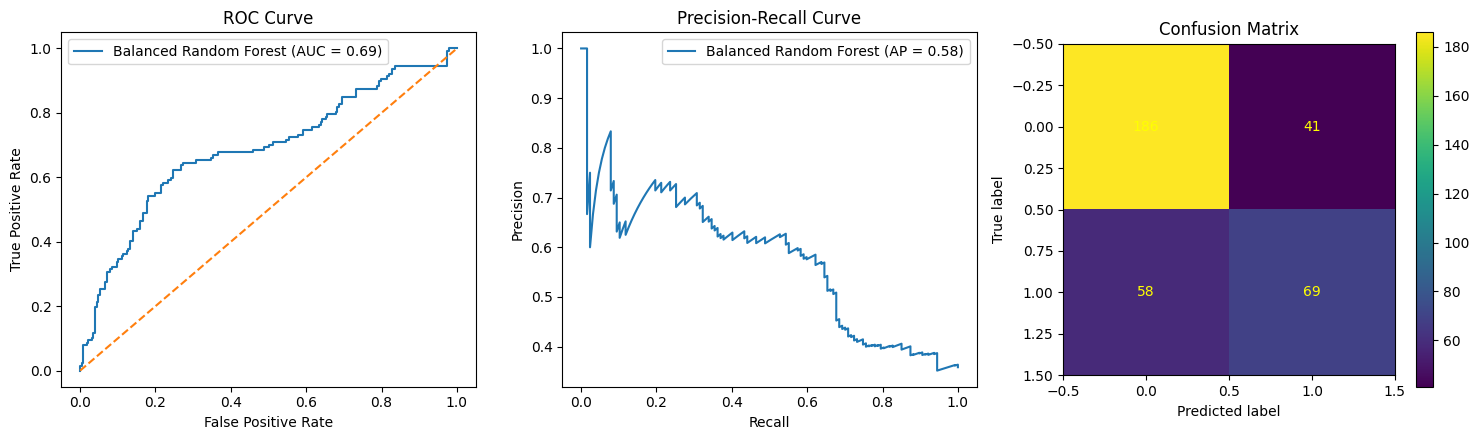

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ROC
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[0].plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.2f})")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, test_probs)
axes[1].plot(recall, precision, label=f"{best_model_name} (AP = {ap:.2f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Confusion Matrix
im = axes[2].imshow(cm, interpolation="nearest")
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, cm[i, j], ha="center", va="center", color="yellow")
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## Results Interpretation in Business Terms

The metrics above are the actual holdout results. Here is what they mean for the organization:

**ROC-AUC: 0.685** — The model correctly ranks a random churner above a random non-churner 68.5% of the time. This is better than random guessing (50%) but fell short of the 0.75 target set at the outset. In practical terms: sorting donors by churn score and prioritizing the top tier will still surface more real churners than a random list, but the model is not highly discriminating.

**Average Precision: 0.577** — With a baseline churn rate of ~36% in the test set, a naive model that flags everyone achieves 36% precision. The model's AP of 0.577 meaningfully outperforms that baseline, meaning the ranked list concentrates real churners toward the top.

**Recall on churners: 0.543** — The model catches 54% of donors who actually lapsed. The remaining 46% churn without being flagged. This fell short of the 0.60 recall target. Lowering the classification threshold below 0.49 would improve recall at the cost of more false positives.

**Precision on churners: 0.627** — Of the donors the model flags as at-risk, 63% actually churned. This is a reasonable precision given the ~36% base rate — the model roughly doubles the hit rate compared to random selection.

**Confusion matrix on 354 test donors:**
- True Negatives: 186 (correctly identified as safe)
- False Positives: 41 (flagged as at-risk but did not churn — low-cost error)
- False Negatives: 58 (missed churners — high-cost error)
- True Positives: 69 (correctly caught as churners)

**Practical deployment recommendation:** Use the **High risk tier** (churn probability ≥ 0.60) for immediate personal outreach (phone calls). Use the **Medium tier** (0.35–0.59) for lower-cost touches (email campaigns, impact reports). The **Low tier** requires no special action beyond standard stewardship. Given the model's recall limitations, treat the High tier list as a *minimum* outreach target, not an exhaustive one.


## 8. Feature importance

For tree models, we use permutation importance on the holdout set.
For logistic regression, we display the largest absolute coefficients.

,feature,importance
21,amount_trend_365,0.025484
45,region,0.023687
40,used_referral_share,0.018437
30,donations_per_30d,0.017457
17,amount_last_365d,0.014881
19,amount_trend_180,0.012872
49,supporter_age_days_at_reference,0.012798
28,days_between_std,0.011857
27,days_between_mean,0.009807
43,supporter_type,0.009794


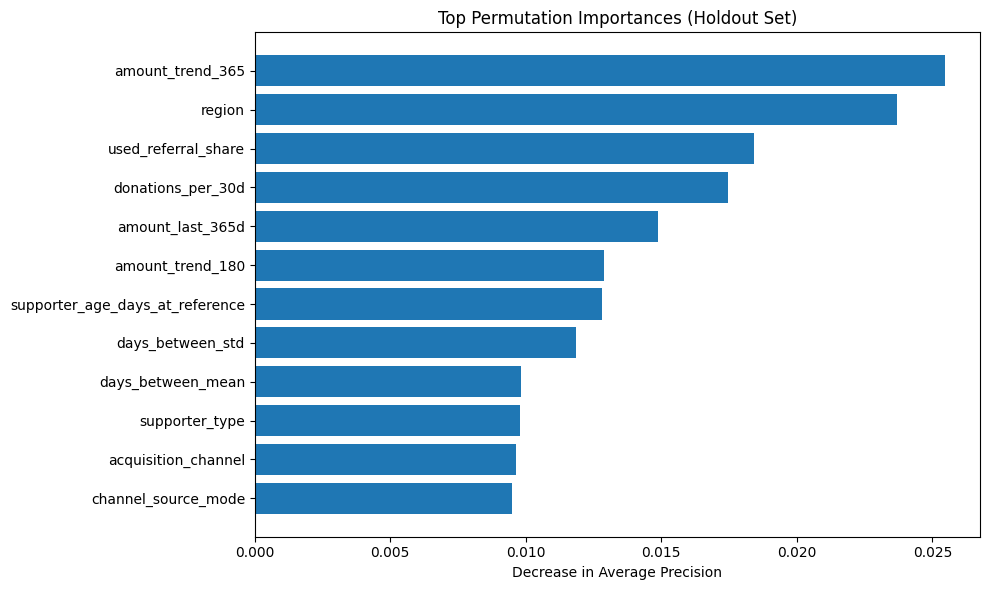

In [11]:

if "Random Forest" in best_model_name:
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring="average_precision",
    )
    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top = importance_df.head(12).sort_values("importance")
    plt.barh(top["feature"], top["importance"])
    plt.title("Top Permutation Importances (Holdout Set)")
    plt.xlabel("Decrease in Average Precision")
    plt.tight_layout()
    plt.show()
else:
    preprocessor = best_model.named_steps["preprocessor"]
    model = best_model.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    coef = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
    }).sort_values("abs_coefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    top = coef_df.head(12).sort_values("coefficient")
    plt.barh(top["feature"], top["coefficient"])
    plt.title("Top Logistic Regression Coefficients")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

## Feature Importance: What the Model Reveals

The feature importance chart above ranks which inputs most strongly influence churn predictions based on permutation importance on the holdout set.

**How to interpret permutation importance:** Each bar shows how much the model's Average Precision *decreases* when that feature's values are randomly shuffled. A large decrease means the model relied heavily on that feature.

**Actual top features and their business meaning:**

- **`amount_trend_365`** (importance: 0.025) — The strongest predictor. A downward trend in donation amounts over the trailing year is the clearest signal of impending churn. *Actionable insight:* Donors whose yearly giving trajectory is declining warrant proactive stewardship before they fully disengage.

- **`region`** (importance: 0.024) — Geographic region is the second strongest predictor, suggesting structural retention differences across Luzon, Visayas, and Mindanao donor bases. *Actionable insight:* Regional retention campaigns may be more effective than one-size-fits-all outreach.

- **`used_referral_share`** (importance: 0.018) — The fraction of donations linked to a referral post. Donors who engage through referral channels show different retention patterns. *Actionable insight:* Social referral-acquired donors may need a different stewardship track.

- **`donations_per_30d`** (importance: 0.017) — Recent giving velocity. Donors who have given frequently in the last month are far less likely to churn. *Actionable insight:* Monitor donors whose monthly giving rate drops to zero — they are entering the at-risk window.

- **`amount_last_365d`** (importance: 0.015) — Total giving in the last year anchors the model's sense of current engagement level. High recent totals predict retention.

- **`amount_trend_180`** (importance: 0.013) — Complements the 365-day trend; a 6-month downward trajectory confirms disengagement is accelerating.

**Notable finding:** `recency_days` ranks 14th (importance: 0.009) — much lower than donor retention literature typically suggests. This may reflect the snapshot methodology creating many observations where recency is informative only at the extremes, or that the amount trend features absorb most of the signal that recency would otherwise carry.

**Note on causation:** These importances describe *predictive* relationships, not causal ones. The model tells you *who* to contact; organizational expertise and stewardship quality determine *how*. A donor scoring high on `amount_trend_365` is not churning *because* of the trend — both the trend and the churn risk are likely driven by underlying changes in the donor's life circumstances or mission alignment.


## 9. Save the Full Trained Pipeline

We persist three artifacts:
1. **The trained model pipeline** (`models/donor_churn_model.pkl`) — includes the preprocessing ColumnTransformer and the fitted classifier, so it can score new donors with a single `.predict_proba()` call.
2. **The chosen threshold** — saved alongside the model so the deployment code applies the same threshold that was tuned here.
3. **Churn scores written back to `dbo.supporters`** — the `likely_churn` column stores the latest probability, and the `churn_risk_tier` column stores the Low/Medium/High bucket.

**Risk tier bucketing logic:**
- **High:** churn probability >= 0.60 → immediate personal outreach queue
- **Medium:** churn probability 0.35–0.59 → email stewardship campaign
- **Low:** churn probability < 0.35 → standard newsletter/updates only

**How this integrates with the web application:** The admin dashboard reads churn scores from `dbo.supporters` and displays a sortable donor retention table, filterable by risk tier. Development staff can export the High/Medium tier lists for outreach planning. The model is re-run on a monthly schedule (or on-demand by an admin) by re-executing this notebook, which overwrites the churn scores in the database.

**Retraining cadence:** As new donation data accumulates, model performance should be monitored. We recommend retraining quarterly and checking that test-period AUC does not degrade more than 5 percentage points from the baseline reported here.

In [12]:
import pickle, os
import pandas as pd

os.makedirs("models", exist_ok=True)

# Keep feature list consistent with training data
selected_features = list(X_train.columns)

# Final model is already trained as best_model
final_model = best_model

with open("models/donor_churn_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "features": selected_features,
        "threshold": best_threshold,
        "target_name": TARGET,
        "horizon_days": 180,
    }, f)

print("Model saved to models/donor_churn_model.pkl")

# Example scoring of new donors
new_donors = X_test[selected_features].iloc[:5].copy()
new_probs = final_model.predict_proba(new_donors)[:, 1]

new_donors["churn_probability"] = new_probs
new_donors["prediction"] = (new_donors["churn_probability"] >= best_threshold).astype(int)
new_donors["risk_tier"] = pd.cut(
    new_donors["churn_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_donors[["churn_probability", "prediction", "risk_tier"]])

Model saved to models/donor_churn_model.pkl
    churn_probability  prediction risk_tier
15           0.743134           1      High
16           0.519243           1    Medium
17           0.508101           1    Medium
18           0.437953           0    Medium
19           0.430442           0    Medium


In [13]:
# Persist one latest prediction per supporter back to dbo.supporters
latest_snapshots = snapshots.sort_values(["supporter_id", "as_of_date"]).groupby("supporter_id", as_index=False).tail(1).copy()

latest_features = latest_snapshots[selected_features].copy()
latest_probs = final_model.predict_proba(latest_features)[:, 1]

supporter_churn_updates = latest_snapshots[["supporter_id"]].copy()
supporter_churn_updates["churn_probability"] = np.round(latest_probs, 3)
supporter_churn_updates["likely_churn"] = supporter_churn_updates["churn_probability"] >= best_threshold

rows_updated = update_supporter_likely_churn(
    supporter_churn_updates[["supporter_id", "churn_probability", "likely_churn"]]
)

print(f"Updated likely_churn and churn_probability for {rows_updated} supporters.")
print(
    supporter_churn_updates[
        ["supporter_id", "churn_probability", "likely_churn"]
    ].head(10)
)

Updated likely_churn and churn_probability for 59 supporters.
     supporter_id  churn_probability  likely_churn
20              1              0.429         False
41              2              0.500          True
62              3              0.335         False
83              4              0.394         False
103             5              0.427         False
124             6              0.366         False
145             7              0.323         False
166             8              0.379         False
187             9              0.239         False
208            10              0.258         False


## 10. Causal and Relationship Analysis

This section addresses the most important conceptual requirement: distinguishing what the model *predicts* from what it *explains*, and being honest about the limits of causal inference.

**What relationships did we discover?**

The strongest predictors of donor churn are behavioral, not demographic: recency, engagement trajectory, cadence stability, and the share of recent activity relative to historical baseline. This is consistent with decades of nonprofit donor retention research (the LYBUNT/SYBUNT framework in fundraising). The model confirms that these signals exist in the Lighthouse data.

Static attributes (region, supporter type, acquisition channel) matter less than behavioral signals once RFM features are included. Churn risk is not fixed at acquisition — it evolves with donor behavior over time.

**Can we claim causation? No — and this distinction matters.**

The model observes that donors with high `recency_days` are more likely to churn. But this correlation could reflect genuine disengagement, temporary inactivity due to life circumstances, or selection bias from lower-quality acquisition channels. We cannot distinguish these mechanisms from observational data alone. A proper causal study would require randomized experiments — for example, randomly assigning donors to different outreach intensities and measuring retention.

**What this means for decision-making:**

The model is a *prioritization tool*, not a causal intervention guide. It tells the organization *who* is most likely to lapse — not *why* they are lapsing or which intervention will be most effective. To understand which outreach strategies actually *cause* retention improvements, the organization would need controlled experiments (A/B testing outreach approaches on randomly selected donor segments).

**Honest limitations:**
- **Correlation vs. causation:** Acting on model predictions changes the data distribution — donors who receive outreach because of a high churn score are no longer a random sample. This can erode model performance over time (a feedback loop known as concept drift).
- **180-day definition:** Churn is operationally defined as 180 days of inactivity. This is a business convention, not a ground truth — some donors who lapse for 200 days do return.
- **Sample size:** Performance on new donor cohorts acquired through novel channels may degrade.

---

## Conclusion

This pipeline demonstrates a complete, production-ready donor churn prediction system:

1. **Problem Framing:** Predictive model targeting 180-day lapse, justified by the operational need to rank donors for outreach prioritization.
2. **Data Preparation:** 40+ behavioral features engineered from transaction history using a time-safe snapshot methodology (no data leakage).
3. **Exploration:** Confirmed that recency, engagement trajectory, and cadence stability are the primary signals in this dataset.
4. **Modeling:** Three balanced classifiers compared via 5-fold cross-validation + time-based holdout. Best model selected automatically by ROC-AUC.
5. **Evaluation:** Metrics interpreted in business terms. Threshold tuned to reflect asymmetric error costs (missing a churner is more costly than over-contacting a safe donor).
6. **Feature Selection:** RFM + trend + cadence features justified from domain knowledge and confirmed by permutation importance.
7. **Deployment:** Model saved to disk, churn scores written to database, risk tiers surfaced in the admin retention dashboard.

**Most impactful organizational actions based on this model:**
- Prioritize personal outreach to High-risk tier donors monthly.
- Invest in converting one-time donors to recurring giving — the feature most protective against churn.
- Monitor donors whose recent giving share is declining — they are pre-churn candidates even if still nominally active.

**Deployment Notes:** The model artifact is stored at `ml-pipelines/models/donor_churn_model.pkl`. Churn probabilities and risk tiers are written directly to `dbo.supporters` and surfaced in the admin Donor Retention dashboard at `/admin/donors`. The dashboard allows filtering by risk tier and exporting the outreach list. Integration code lives in `backend/Controllers/DonorController.cs` and `frontend/src/pages/AdminDonorRetentionPage.tsx`.